In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.inspection import PartialDependenceDisplay

In [12]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Remove customerID
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Convert Churn
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

print(df.head())
print(df.shape)

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

/tmp/ipykernel_7279/1331123198.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (5634, 30)
Test Shape : (1409, 30)


In [14]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


Accuracy : 0.8005677785663591
ROC-AUC  : 0.8417628975173732

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



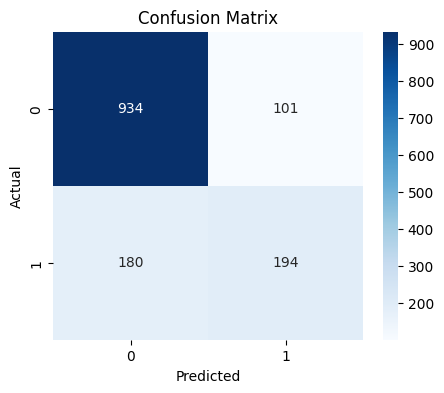

In [15]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

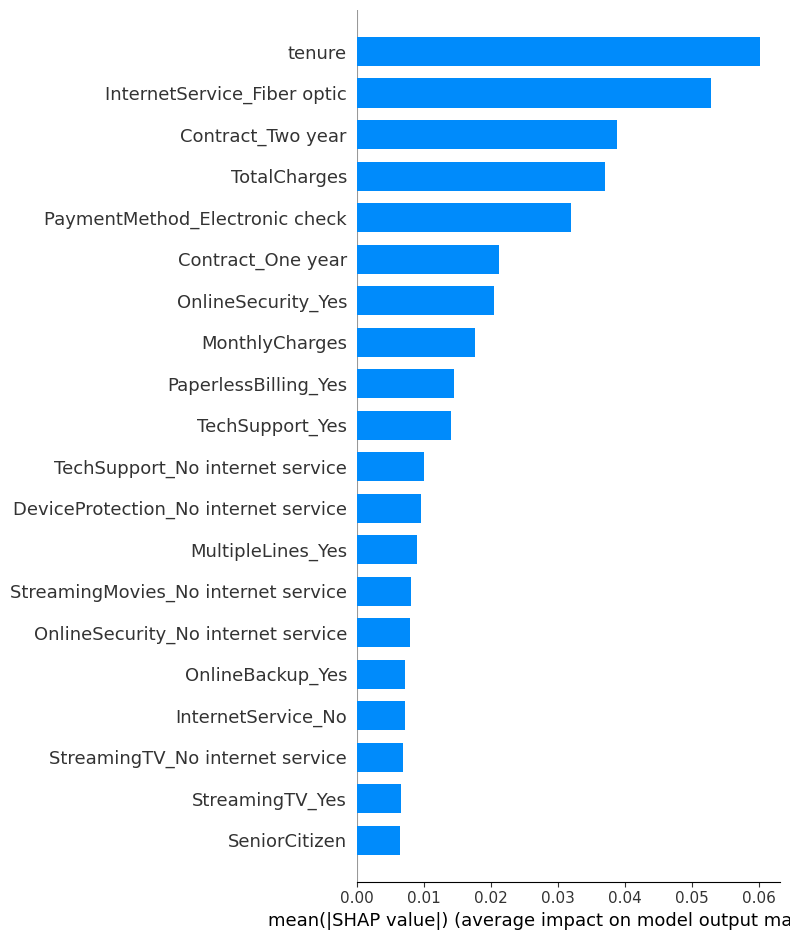

In [16]:
explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

# Handle different SHAP versions
if isinstance(shap_values, list):
    shap_class1 = shap_values[1]
else:
    shap_class1 = shap_values

if len(np.array(shap_class1).shape) == 3:
    shap_class1 = shap_class1[:, :, 1]

# Global feature importance
shap.summary_plot(
    shap_class1,
    X_test,
    plot_type="bar"
)

In [17]:
# Churned customer
churn_idx = y_test[y_test == 1].index[0]

# Retained customer
retain_idx = y_test[y_test == 0].index[0]

print("Churned Customer Data:")
print(X_test.loc[churn_idx])

print("\nPredicted Churn Probability:")
print(y_prob[X_test.index.get_loc(churn_idx)])

print("\nRetained Customer Data:")
print(X_test.loc[retain_idx])

print("\nPredicted Churn Probability:")
print(y_prob[X_test.index.get_loc(retain_idx)])

Churned Customer Data:
SeniorCitizen                                1
tenure                                      17
MonthlyCharges                           45.05
TotalCharges                             770.6
gender_Male                               True
Partner_Yes                              False
Dependents_Yes                           False
PhoneService_Yes                          True
MultipleLines_No phone service           False
MultipleLines_Yes                        False
InternetService_Fiber optic              False
InternetService_No                       False
OnlineSecurity_No internet service       False
OnlineSecurity_Yes                       False
OnlineBackup_No internet service         False
OnlineBackup_Yes                         False
DeviceProtection_No internet service     False
DeviceProtection_Yes                     False
TechSupport_No internet service          False
TechSupport_Yes                          False
StreamingTV_No internet service      

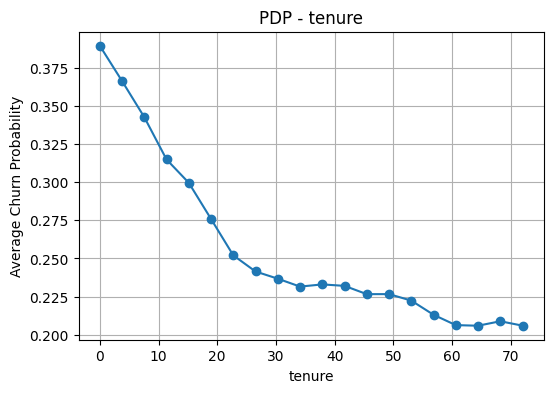

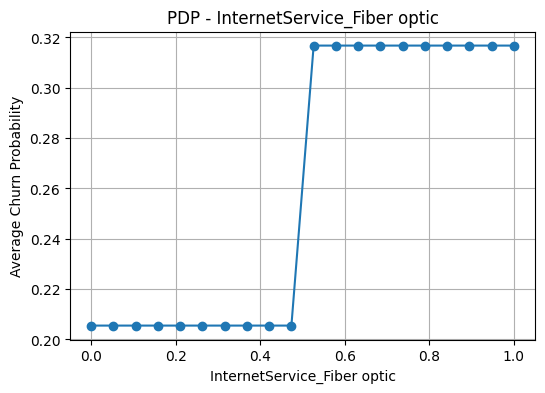

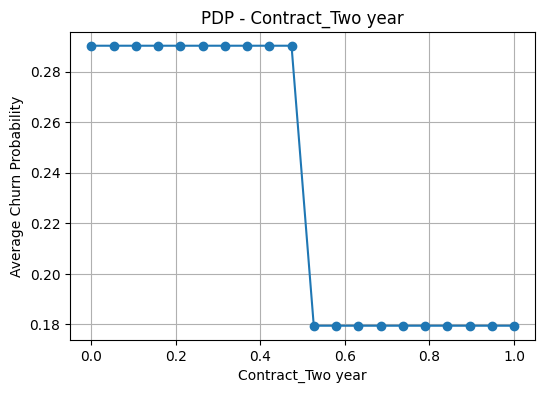

In [21]:
for feature in top3_features:

    values = np.linspace(
        X_test[feature].min(),
        X_test[feature].max(),
        20
    )

    avg_preds = []

    for val in values:
        temp = X_test.copy()
        temp[feature] = val

        preds = best_model.predict_proba(temp)[:,1]
        avg_preds.append(preds.mean())

    plt.figure(figsize=(6,4))
    plt.plot(values, avg_preds, marker='o')

    plt.xlabel(feature)
    plt.ylabel("Average Churn Probability")
    plt.title(f"PDP - {feature}")
    plt.grid(True)
    plt.show()

Top 5 Factors Driving Churn:
tenure                            0.060063
InternetService_Fiber optic       0.052744
Contract_Two year                 0.038769
TotalCharges                      0.036931
PaymentMethod_Electronic check    0.031893
dtype: float64


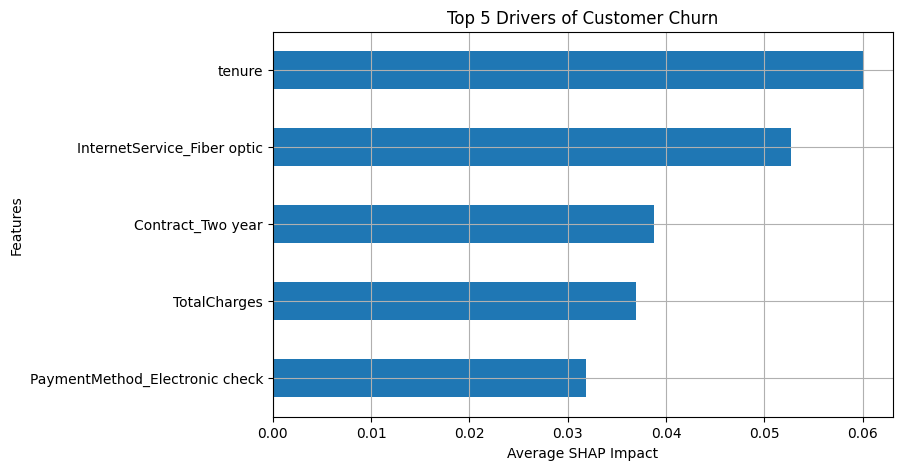

In [22]:
top5 = feature_importance.head(5)

print("Top 5 Factors Driving Churn:")
print(top5)

plt.figure(figsize=(8,5))
top5.sort_values().plot(kind="barh")

plt.title("Top 5 Drivers of Customer Churn")
plt.xlabel("Average SHAP Impact")
plt.ylabel("Features")
plt.grid(True)
plt.show()

In [23]:
risk_data = X_test.copy()
risk_data["Actual_Churn"] = y_test.values
risk_data["Predicted_Prob"] = y_prob

# Highest risk customers
high_risk = risk_data.sort_values(
    by="Predicted_Prob",
    ascending=False
).head(20)

print("Top High Risk Customers:")
print(high_risk[["Predicted_Prob"]])

print("""
Highest risk segments usually include:

1. Low tenure customers
2. Fiber optic users
3. Month-to-month contracts
4. Higher monthly charges
5. Electronic check payment users
""")

Top High Risk Customers:
      Predicted_Prob
4585        0.906318
6866        0.895209
3380        0.880774
6623        0.873117
1731        0.871402
809         0.871216
1739        0.865711
2927        0.865711
3682        0.862388
2753        0.854944
2194        0.847904
2464        0.847597
6190        0.844862
2631        0.843919
2797        0.840882
6748        0.840838
6365        0.839994
6633        0.838091
3346        0.835265
2900        0.833898

Highest risk segments usually include:

1. Low tenure customers
2. Fiber optic users
3. Month-to-month contracts
4. Higher monthly charges
5. Electronic check payment users



In [24]:
print("""
Recommended Pricing Strategy Based on Model Insights:

1. Customers with high MonthlyCharges show higher churn risk.

2. Offer discounts to high-bill customers who are on
   month-to-month contracts.

3. Promote long-term contracts (1 year / 2 year)
   with lower monthly pricing.

4. Bundle internet + phone + streaming services
   at discounted combined rates.

5. Give loyalty discounts to long-tenure customers
   to prevent future churn.
""")


Recommended Pricing Strategy Based on Model Insights:

1. Customers with high MonthlyCharges show higher churn risk.

2. Offer discounts to high-bill customers who are on
   month-to-month contracts.

3. Promote long-term contracts (1 year / 2 year)
   with lower monthly pricing.

4. Bundle internet + phone + streaming services
   at discounted combined rates.

5. Give loyalty discounts to long-tenure customers
   to prevent future churn.



In [25]:
top100 = risk_data.sort_values(
    by="Predicted_Prob",
    ascending=False
).head(100)

print("Top 100 Customers to Target:")
print(top100[["Predicted_Prob"]].head(20))

print("""
Why target them?

These customers have the highest predicted probability
of churn, so intervention here gives maximum expected
retention benefit.
""")

Top 100 Customers to Target:
      Predicted_Prob
4585        0.906318
6866        0.895209
3380        0.880774
6623        0.873117
1731        0.871402
809         0.871216
1739        0.865711
2927        0.865711
3682        0.862388
2753        0.854944
2194        0.847904
2464        0.847597
6190        0.844862
2631        0.843919
2797        0.840882
6748        0.840838
6365        0.839994
6633        0.838091
3346        0.835265
2900        0.833898

Why target them?

These customers have the highest predicted probability
of churn, so intervention here gives maximum expected
retention benefit.



In [26]:
# Model targeting top 100 customers
targeted = top100.copy()

# Expected churners among top 100
actual_churners = targeted["Actual_Churn"].sum()

# Costs
retention_cost = 100 * 50

# Savings
saved_revenue = actual_churners * 500

# Net Profit
net_profit = saved_revenue - retention_cost

# ROI %
roi = (net_profit / retention_cost) * 100

print("MODEL TARGETING RESULTS")
print("Actual churners found in top 100 :", actual_churners)
print("Retention Cost                  :", retention_cost)
print("Saved Revenue                   :", saved_revenue)
print("Net Profit                      :", net_profit)
print("ROI %                           :", roi)

# Random targeting baseline
random_expected = y_test.mean() * 100

random_saved = random_expected * 500
random_profit = random_saved - retention_cost
random_roi = (random_profit / retention_cost) * 100

print("\nRANDOM TARGETING RESULTS")
print("Expected churners found :", round(random_expected,2))
print("Net Profit              :", round(random_profit,2))
print("ROI %                   :", round(random_roi,2))

MODEL TARGETING RESULTS
Actual churners found in top 100 : 79
Retention Cost                  : 5000
Saved Revenue                   : 39500
Net Profit                      : 34500
ROI %                           : 690.0

RANDOM TARGETING RESULTS
Expected churners found : 26.54
Net Profit              : 8271.82
ROI %                   : 165.44
